# Online Retail II Dataset - Exploratory Data Analysis (EDA)

## Objective
The objective of this analysis is to explore the Online Retail II dataset to understand customer purchase behavior, identify data quality issues, analyze sales performance, and derive business insights before implementing a recommendation system.

### Tasks
- Load and explore the dataset
- Identify missing values and duplicates
- Analyze top-selling products
- Analyze sales by country
- Visualize monthly revenue trends
- Create a correlation heatmap
- Detect outliers using box plots
- Provide business insights

## Import Required Libraries

Import the libraries required for data analysis and visualization.

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

## Load the Dataset

Load the uploaded Excel file into a Pandas DataFrame.

In [29]:
df = pd.read_excel("online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Display Basic Information

Explore the dataset by checking its shape, columns, and data types.

In [30]:
# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (525461, 8)

Column Names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


## Dataset Summary

Display summary statistics and general information about the dataset.

In [31]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [32]:
# Summary statistics for numerical columns
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [33]:
# Summary statistics for all columns
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.0,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816.0,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


## Check Missing Values

Identify missing values in each column of the dataset.

In [34]:
# Display missing values in a table
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_df

,Missing Values,Percentage
Invoice,0,0.000000
StockCode,0,0.000000
Description,2928,0.557225
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,107927,20.539488
Country,0,0.000000


## Check Duplicate Rows

Identify duplicate records in the dataset.

In [35]:
# Count duplicate rows
duplicate_rows = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 6865


## Top 10 Best-Selling Products by Quantity

Identify the products with the highest total quantity sold.

In [36]:
# Top 10 products by quantity sold
top_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity

,Quantity
Description,
WHITE HANGING HEART T-LIGHT HOLDER,57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54698
BROCADE RING PURSE,47647
PACK OF 72 RETRO SPOT CAKE CASES,46106
ASSORTED COLOUR BIRD ORNAMENT,44925
60 TEATIME FAIRY CAKE CASES,36326
PACK OF 60 PINK PAISLEY CAKE CASES,31822
JUMBO BAG RED RETROSPOT,30727
SMALL POPCORN HOLDER,29500


## Visualization of Top 10 Products by Quantity

Visualize the top-selling products based on total quantity sold.

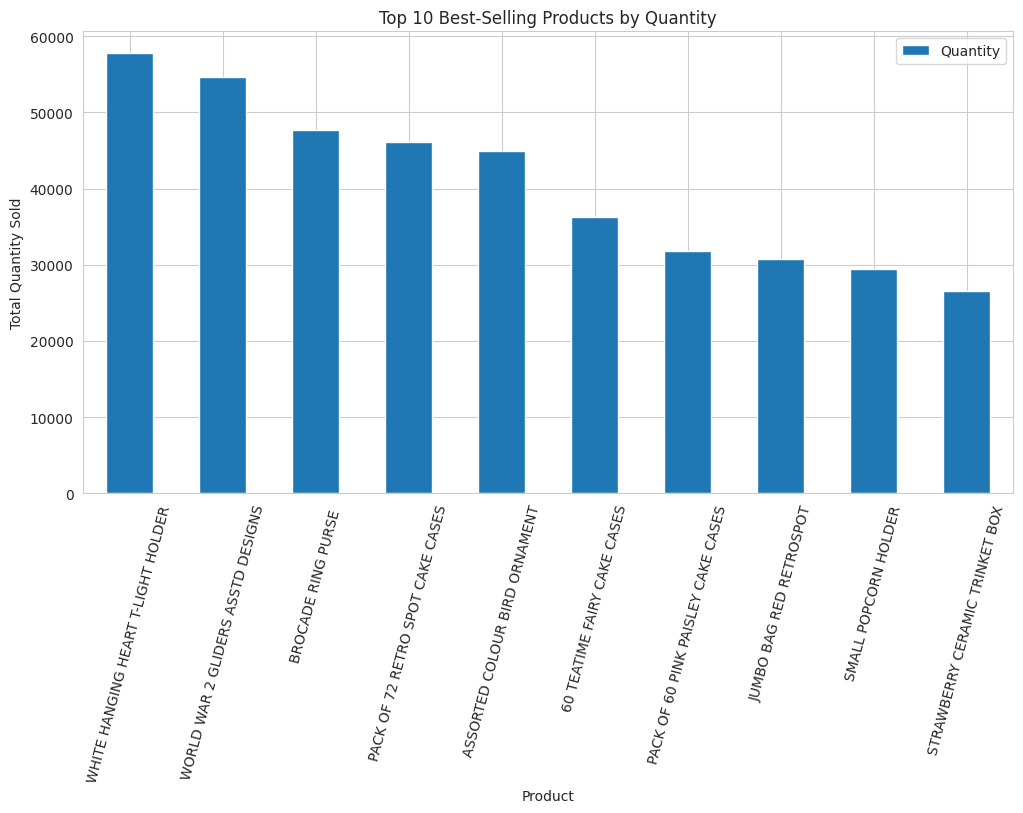

In [37]:
plt.figure(figsize=(12, 6))

top_quantity.plot(kind="bar")

plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=75)
plt.legend(["Quantity"])

plt.show()

## Calculate Product Revenue

Calculate the revenue generated by each transaction.

In [38]:
# Create a Revenue column
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## Top 10 Products by Revenue

Identify the products that generated the highest revenue.

In [39]:
top_revenue = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,163051.46
WHITE HANGING HEART T-LIGHT HOLDER,157865.43
DOTCOM POSTAGE,116401.99
ASSORTED COLOUR BIRD ORNAMENT,72454.12
PAPER CHAIN KIT 50'S CHRISTMAS,57870.20
JUMBO BAG RED RETROSPOT,56444.61
PARTY BUNTING,49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR,47672.49
POSTAGE,46092.36


## Visualization of Top 10 Products by Revenue

Visualize the highest revenue-generating products.

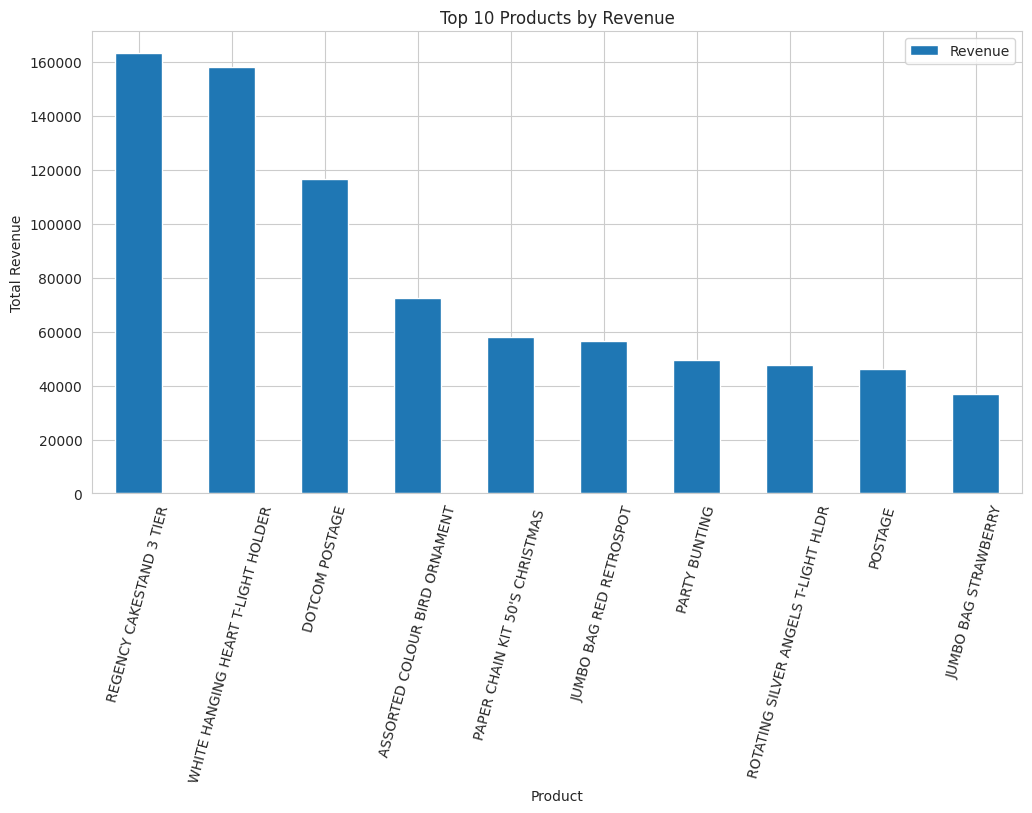

In [40]:
plt.figure(figsize=(12,6))

top_revenue.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=75)
plt.legend(["Revenue"])

plt.show()

## Sales Performance by Country

Analyze the revenue generated by each country.

In [41]:
# Revenue by country
country_sales = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

,Revenue
Country,
United Kingdom,8194777.533
EIRE,352242.730
Netherlands,263863.410
Germany,196290.351
France,130769.900
Sweden,51213.510
Denmark,46972.950
Switzerland,43343.410
Spain,37084.900


## Top 10 Countries by Revenue

Visualize the countries generating the highest revenue.

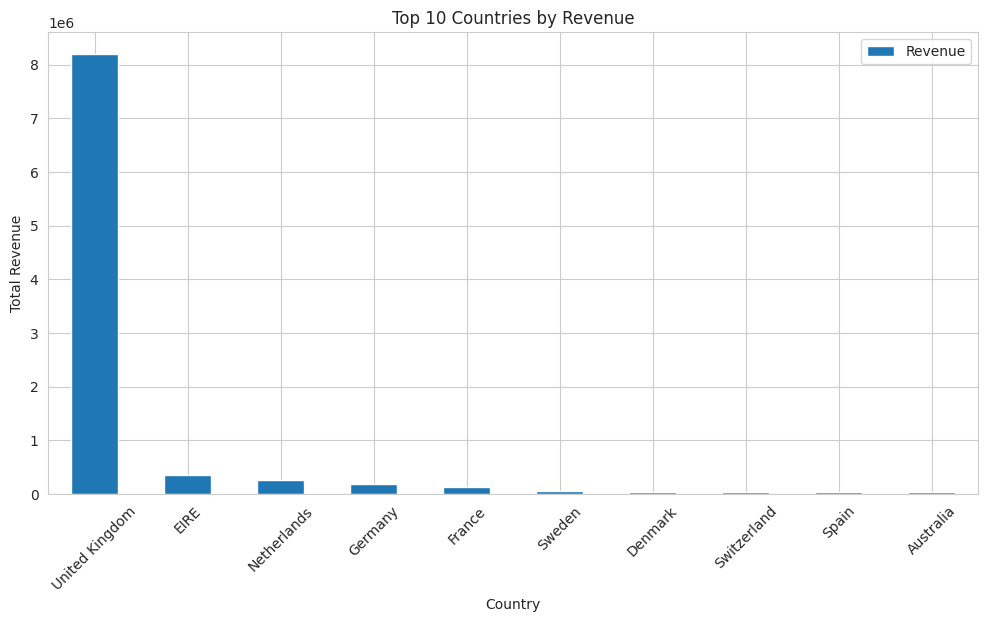

In [42]:
plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(["Revenue"])

plt.show()

## Monthly Revenue Trend

Analyze how revenue changes over time on a monthly basis.

In [43]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create Month-Year column
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [44]:
# Monthly revenue
monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue

,Revenue
Month,
2009-12,799847.110
2010-01,624032.892
2010-02,533091.426
2010-03,765848.761
2010-04,590580.432
2010-05,615322.830
2010-06,679786.610
2010-07,575236.360
2010-08,656776.340


## Monthly Revenue Visualization

Visualize the monthly revenue trend.

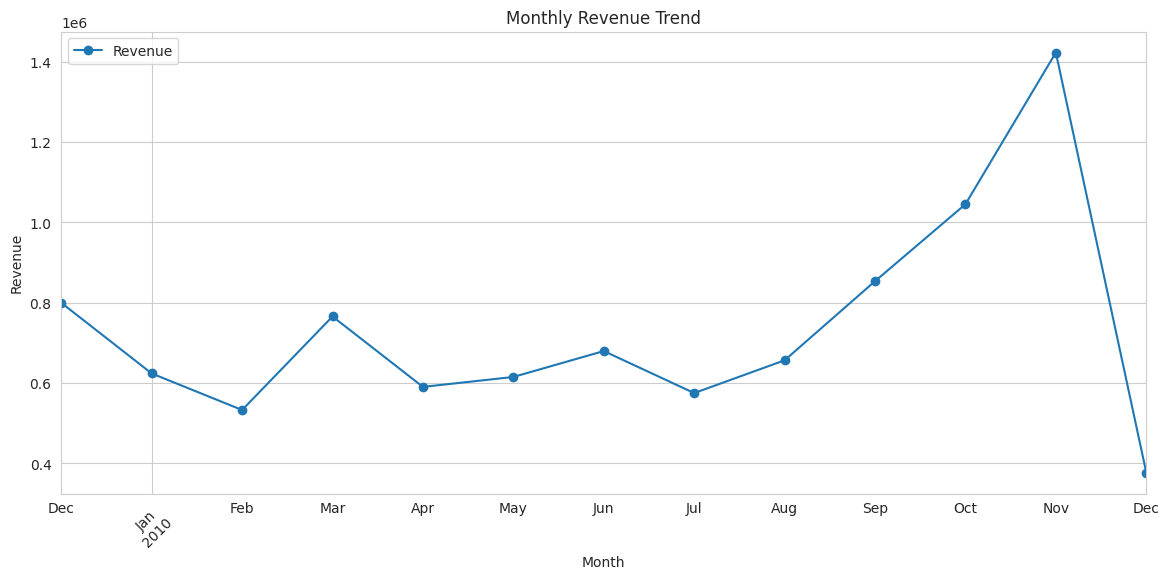

In [45]:
plt.figure(figsize=(14,6))

monthly_revenue.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(["Revenue"])

plt.show()

## Correlation Heatmap

Analyze the relationship between numerical features using a correlation heatmap.

In [46]:
# Select numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Correlation matrix
correlation = numeric_df.corr()

correlation

,Quantity,Price,Customer ID,Revenue
Quantity,1.000000,-0.001931,-0.011577,0.156283
Price,-0.001931,1.000000,-0.003266,0.452592
Customer ID,-0.011577,-0.003266,1.000000,-0.009475
Revenue,0.156283,0.452592,-0.009475,1.000000


## Correlation Heatmap Visualization

Visualize the correlation between numerical features.

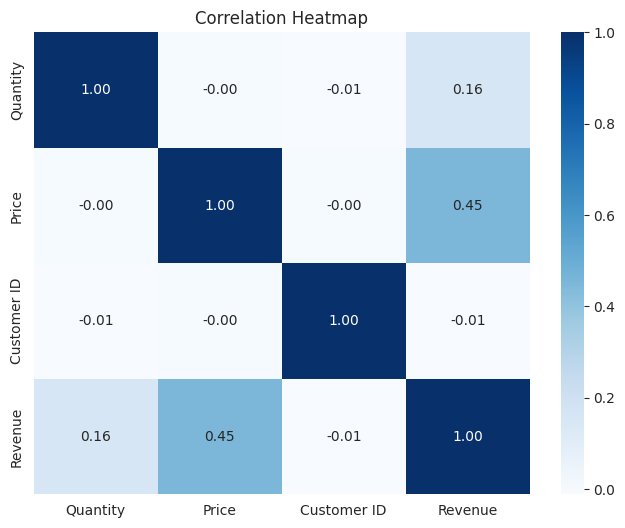

In [47]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Outlier Detection

Visualize outliers in numerical features using box plots.

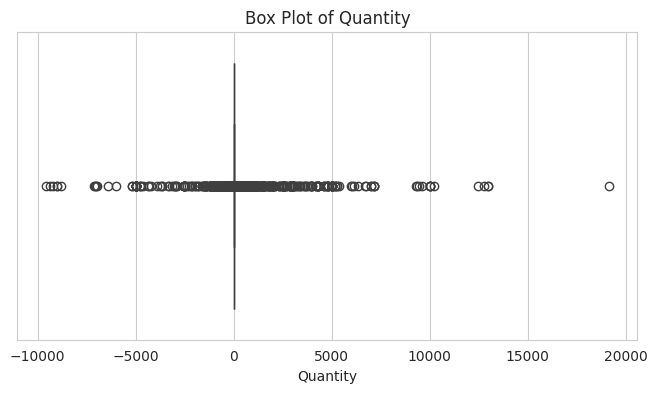

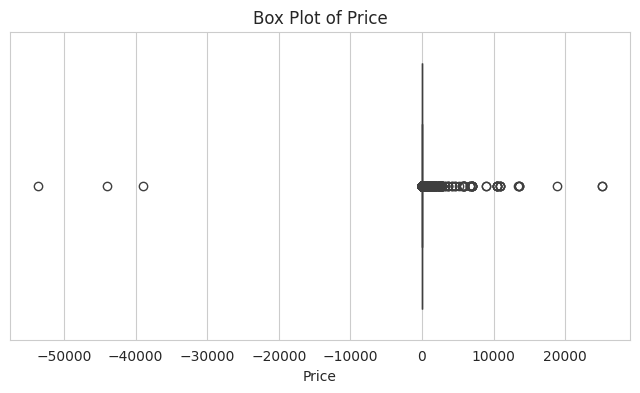

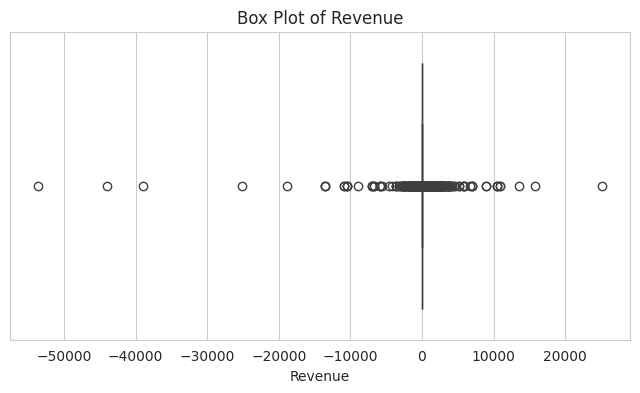

In [48]:
# Numerical columns
numeric_columns = ["Quantity", "Price", "Revenue"]

for column in numeric_columns:
    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[column])

    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)

    plt.show()

## Business Insights

1. **White Hanging Heart T-Light Holder** is the highest-selling product by quantity, indicating strong and consistent customer demand for this item.

2. **Regency Cake Stand 3 Tier** generates the highest total revenue, showing that premium-priced products contribute significantly to overall sales.

3. **The United Kingdom is the company's largest market**, contributing the highest revenue compared to all other countries, while international sales account for a much smaller share.

4. **Monthly revenue shows noticeable fluctuations**, with higher sales during the later months of the year, suggesting seasonal purchasing behavior and increased customer activity during peak shopping periods.

5. **The dataset contains missing values, duplicate records, and several outliers in Quantity, Price, and Revenue.** These issues should be addressed during data preprocessing before developing predictive models or recommendation systems.

## Conclusion

This exploratory data analysis provided an overview of customer purchasing behavior, product performance, sales by country, revenue trends, and data quality issues. These findings can support future business decisions and serve as a foundation for building recommendation systems and predictive models.